In [3]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
import json
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [4]:
import utils.config as config
importlib.reload(config)
import utils.common as common
importlib.reload(common)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *
import scripts.openkarst.run_openkarst as ok
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
importlib.reload(ok)

<module 'scripts.openkarst.run_openkarst' from 'c:\\Users\\huan1428\\Documents\\karst\\UMNBearSpring\\src\\scripts\\openkarst\\run_openkarst.py'>

# Load Network

In [18]:
network_dir = '../../data/networks/single_conduit/pykasso_n58'
network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv')
network.extract_diffuse_inlets()

In [19]:
network.plot_3D_network(node_color = 'type')

# Load and Write Recharge

In [5]:
#just a box injection for 1 day
from scipy.stats import norm

baseflow = 0.02 #m3/s
peakflow = baseflow * 10
duration = 6 * 3600 # seconds
dt = 1800 
t = np.arange(0, 24*3600, dt)
def gaussian_recharge(t, peak, center, duration):
    """
    t        : time array
    peak    : max recharge value
    center  : time of peak
    duration: FWHM (event duration)
    """

    sigma = duration / 2.355

    return peak * np.exp(-(t-center)**2 / (2*sigma**2))

gauss_R  = gaussian_recharge(t, peakflow - baseflow, 12*3600, duration) + baseflow
#TO DO: partition recharge, save recharge/BC files, run test model


In [8]:
gauss_R_dict = {'flow' : gauss_R, 'time' : t}
write_pickle( f'input_data/gaussian_recharge.pkl', gauss_R_dict)

In [ ]:
R = {network.inlets : {'flow' : rech_limited_range['R_h_per_inlet'], 'time' : rech_limited_range['time (s)']}, 
                                    network.diffuse_inlets: {'flow' : rech_limited_range['R_o_per_inlet'], 'time' : rech_limited_range['time (s)']}}
with open(f'input_data/initial_conditions.pkl', 'wb') as f:
    pickle.dump(IC, f)
    print (f'results saved to input_data/initial_conditions.pkl')
with open(f'input_data/head_boundary.pkl', 'wb') as f:
    pickle.dump(HB, f)
    print (f'results saved to input_data/head_boundary.pkl')
with open(f'input_data/inflow_boundary.pkl', 'wb') as f:
    pickle.dump(R, f)
    print (f'results saved to input_data/inflow_boundary.pkl')

array([0.02000274, 0.02000678, 0.02001612, 0.02003691, 0.02008128,
       0.02017225, 0.02035123, 0.02068913, 0.02130103, 0.02236346,
       0.02413124, 0.02694845, 0.03124523, 0.03751147, 0.04623918,
       0.05783132, 0.07248392, 0.09006072, 0.10999047, 0.13122232,
       0.15226988, 0.17135735, 0.18665549, 0.1965669 , 0.2       ,
       0.1965669 , 0.18665549, 0.17135735, 0.15226988, 0.13122232,
       0.10999047, 0.09006072, 0.07248392, 0.05783132, 0.04623918,
       0.03751147, 0.03124523, 0.02694845, 0.02413124, 0.02236346,
       0.02130103, 0.02068913, 0.02035123, 0.02017225, 0.02008128,
       0.02003691, 0.02001612, 0.02000678])

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, '0.0'),
  Text(1, 0, '0.5'),
  Text(2, 0, '1.0'),
  Text(3, 0, '1.5'),
  Text(4, 0, '2.0'),
  Text(5, 0, '2.5'),
  Text(6, 0, '3.0'),
  Text(7, 0, '3.5'),
  Text(8, 0, '4.0'),
  Text(9, 0, '4.5'),
  Text(10, 0, '5.0'),
  Text(11, 0, '5.5'),
  Text(12, 0, '6.0'),
  Text(13, 0, '6.5'),
  Text(14, 0, '7.0'),
  Text(15, 0, '7.5'),
  Text(16, 0, '8.0'),
  Text(17, 0, '8.5'),
  Text(18, 0, '9.0'),
  Text(19, 0, '9.5'),
  Text(20, 0, '10.0'),
  Text(21, 0, '10.5'),
  Text(22, 0, '11.0'),
  Text(23, 0, '11.5'),
  Text(24, 0, '12.0'),
  Text(25, 0, '12.5'),
  Text(26, 0, '13.0'),
  Text(27, 0, '13.5'),
  Text(28, 0, '14.0'),
  Text(29, 0, '14.5'),
  Text(30, 0, '15.0'),
  Text(31, 0, '15.5'),
  Text(32, 0, '

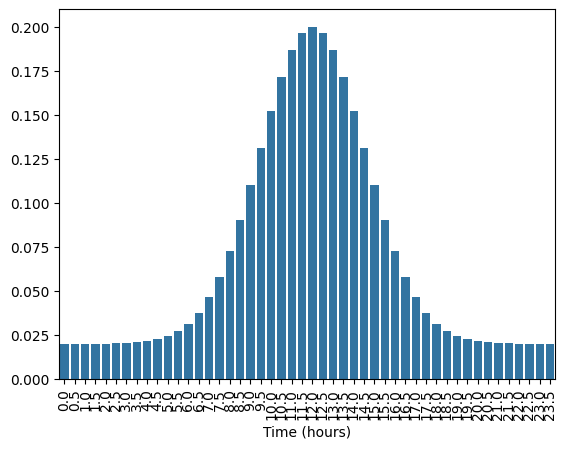

In [38]:
sns.barplot(x=t/3600, y=gauss_R)
plt.xlabel('Time (hours)')
plt.xticks(rotation=90)
